#Predicción de Series de Tiempo

##Preparando los datos

In [1]:
# Utilizar la versión 2 de Tensor Flow
#%tensorflow_version 2.x
#!pip install q keras==2.10.0
#import keras
#keras.__version__

In [2]:
# Cargar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as st
%matplotlib inline
from statsmodels.tools.eval_measures import rmse
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error
#from tensorflow.python.keras.preprocessing.sequence import TimeseriesGenerator
#from tensorflow.python.keras.models import Sequential
#from tensorflow.python.keras.layers import Dense
#from tensorflow.python.keras.layers import LSTM
#from tensorflow.python.keras.layers import Bidirectional
#from tensorflow.python.keras.layers import Dropout
#from keras.preprocessing.sequence import TimeseriesGenerator
#from keras.models import Sequential
#from keras.layers import Dense
#from keras.layers import LSTM
#from keras.layers import Bidirectional
#from keras.layers import Dropout
#from keras.metrics import RootMeanSquaredError
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import RootMeanSquaredError
import warnings
#import keras.backend as K
import tensorflow.keras.backend as K
#warnings.filterwarnings("ignore")

In [3]:
# Habilitar conexión a Drive (solo la primera vez)
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [4]:
# Cargar data
df = pd.read_csv('/content/gdrive/My Drive/Colab Notebooks/SRN/Canales/canales.csv', delimiter='|')
df

,Fecha,tx,rx,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,2026/01/01,110329745257,431683541598,NaN,NaN,NaN,NaN
1,2026/01/02,120805578923,448179990531,NaN,NaN,NaN,NaN
2,2026/01/03,76849863179,415935774705,NaN,NaN,NaN,NaN
3,2026/01/04,123895467793,347089878022,NaN,NaN,NaN,NaN
4,2026/01/05,162992697083,384847512126,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
207,2026/07/27,245507925894,723395167556,NaN,NaN,NaN,NaN
208,2026/07/28,300106002975,535685233562,NaN,NaN,NaN,NaN
209,2026/07/29,269458575025,606503416012,NaN,NaN,NaN,NaN
210,2026/07/30,262734421940,612255527436,NaN,NaN,NaN,NaN


In [5]:
# Convertir la Fecha en indice
df.Fecha = pd.to_datetime(df.Fecha)
df=df.set_index('Fecha')
df

,tx,rx,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
Fecha,,,,,,
2026-01-01,110329745257,431683541598,NaN,NaN,NaN,NaN
2026-01-02,120805578923,448179990531,NaN,NaN,NaN,NaN
2026-01-03,76849863179,415935774705,NaN,NaN,NaN,NaN
2026-01-04,123895467793,347089878022,NaN,NaN,NaN,NaN
2026-01-05,162992697083,384847512126,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-07-27,245507925894,723395167556,NaN,NaN,NaN,NaN
2026-07-28,300106002975,535685233562,NaN,NaN,NaN,NaN
2026-07-29,269458575025,606503416012,NaN,NaN,NaN,NaN


In [6]:
# Agregar el intervalo de predicción
n_future = 153

from pandas.tseries.offsets import DateOffset
add_dates = [df.index[-1] + DateOffset(days=x) for x in range(0,n_future+1)]
future_dates = pd.DataFrame(index=add_dates[1:],columns=df.columns)

df_proj = pd.concat([df,future_dates])
df_proj

,tx,rx,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
2026-01-01,110329745257,431683541598,NaN,NaN,NaN,NaN
2026-01-02,120805578923,448179990531,NaN,NaN,NaN,NaN
2026-01-03,76849863179,415935774705,NaN,NaN,NaN,NaN
2026-01-04,123895467793,347089878022,NaN,NaN,NaN,NaN
2026-01-05,162992697083,384847512126,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-12-27,NaN,NaN,NaN,NaN,NaN,NaN
2026-12-28,NaN,NaN,NaN,NaN,NaN,NaN
2026-12-29,NaN,NaN,NaN,NaN,NaN,NaN
2026-12-30,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Consumo Canal')

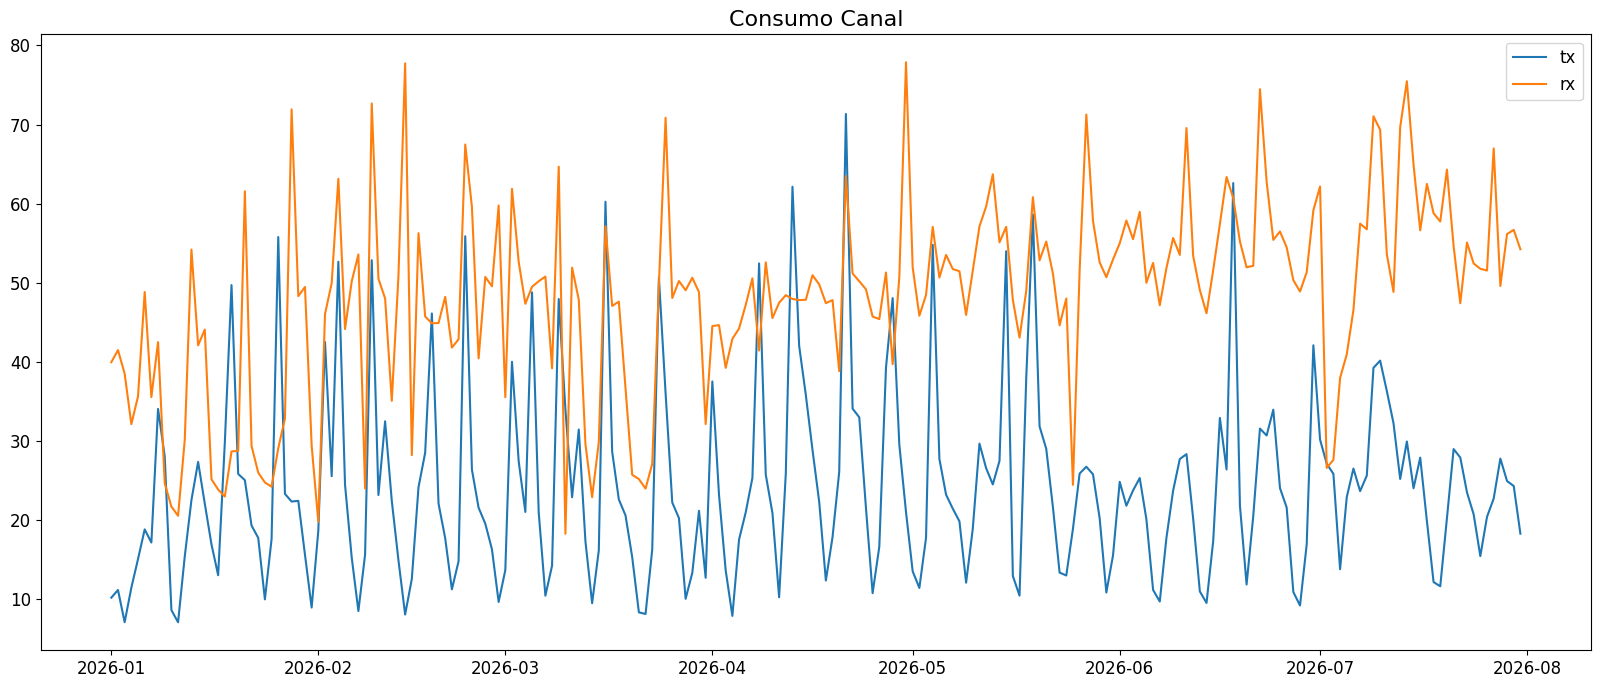

In [7]:
# Ver la data
plt.figure(figsize=(20, 8))
plt.plot(df_proj.index, df_proj['tx']/10800000000, label='tx')
plt.plot(df_proj.index, df_proj['rx']/10800000000, label='rx')
plt.legend(loc='best', fontsize='large')
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.title("Consumo Canal",fontsize=16, color='black')

np.float64(498163234830.0)

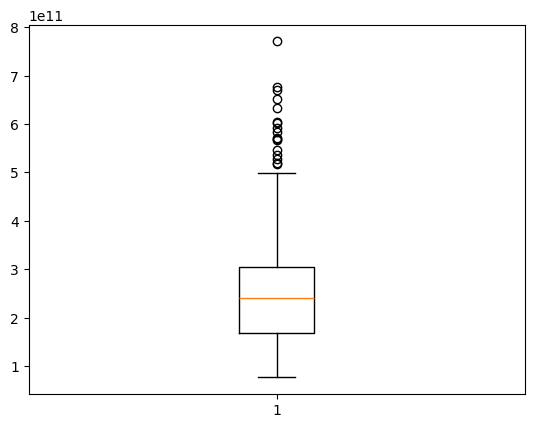

In [8]:
# Ver outliers
txOut = plt.boxplot(df.tx)['whiskers'][1].get_ydata()[1]
txOut

np.float64(784712969656.0)

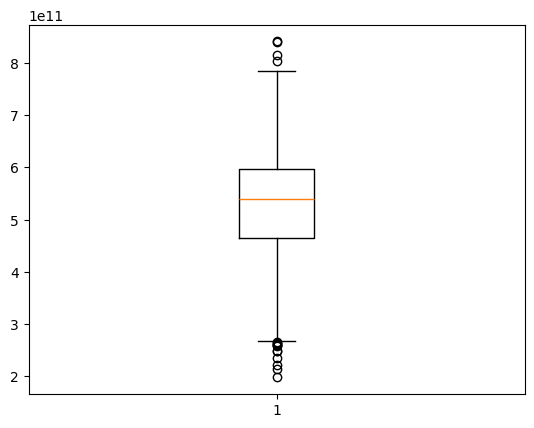

In [9]:
rxOut = plt.boxplot(df.rx)['whiskers'][1].get_ydata()[1]
rxOut

In [10]:
# Reemplazar los outliers con la madiana del mes anterior para ese día
"""for i in range(len(df)):
  if df.tx[i] > txOut:
    df.loc[df.index[i],'tx'] = st.median((df.tx[i-28],df.tx[i-21],df.tx[i-14],df.tx[i-7]))
  if df.rx[i] > rxOut:
    df.loc[df.index[i],'rx'] = st.median((df.rx[i-28],df.rx[i-21],df.rx[i-14],df.rx[i-7]))"""

"for i in range(len(df)):\n  if df.tx[i] > txOut:\n    df.loc[df.index[i],'tx'] = st.median((df.tx[i-28],df.tx[i-21],df.tx[i-14],df.tx[i-7]))\n  if df.rx[i] > rxOut:\n    df.loc[df.index[i],'rx'] = st.median((df.rx[i-28],df.rx[i-21],df.rx[i-14],df.rx[i-7]))"

Text(0.5, 1.0, 'Consumo Canal sin Outliers')

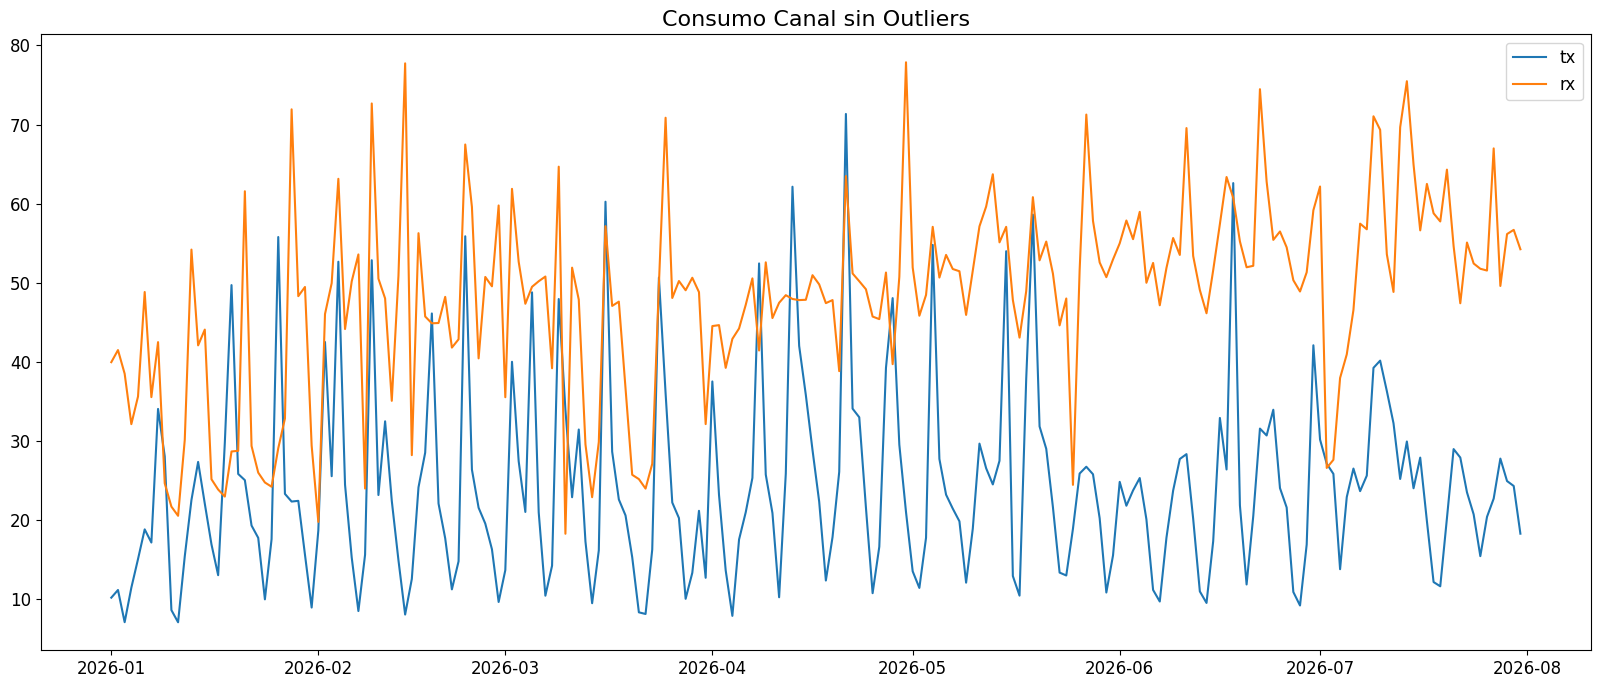

In [11]:
# Ver la data sin outliers
plt.figure(figsize=(20, 8))
plt.plot(df.index, df['tx']/10800000000, label='tx')
plt.plot(df.index, df['rx']/10800000000, label='rx')
plt.legend(loc='best', fontsize='large')
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.title("Consumo Canal sin Outliers",fontsize=16, color='black')

##Preprocesamiento de datos

In [12]:
#temporal para analisis
#df = df[df.index < "2020-01-01"]
#df

In [13]:
# Separar la data para entrenamiento
#split = int(len(df)*0.33)
split = 30

train, val = df[:-split], df[-split:]

In [14]:
# Escalar la data de -1 a 1
def scalerx(train, val=[[0]]):
  scaler = MinMaxScaler(feature_range=(-1, 1))
  scaler.fit(train)
  return scaler, scaler.transform(train), scaler.transform(val)

scalertx, traintx, valtx = scalerx(train[['tx']], val[['tx']])
scalerrx, trainrx, valrx = scalerx(train[['rx']], val[['rx']])

#scalerweek = 53
scalerday, trainday, valday = scalerx(np.asarray(train.index.dayofyear).reshape(-1,1),
                                np.asarray(val.index.dayofyear).reshape(-1,1))

_, df_projday, _ = scalerx(np.asarray(df_proj.index.dayofyear).reshape(-1,1))

In [15]:
# Construir las entradas y salidas
trainEntradas = np.hstack((traintx,
                           trainrx,
                           trainday))

valEntradas = np.hstack((valtx,
                         valrx,
                         valday))

trainSalidas = np.hstack((traintx,
                          trainrx))

valSalidas = np.hstack((valtx,
                        valrx))

trainEntradas[:5], trainSalidas[:5]

(array([[-0.90315181, -0.2721295 , -1.        ],
        [-0.87294746, -0.2208496 , -0.98895028],
        [-0.99968234, -0.32108209, -0.97790055],
        [-0.86403857, -0.53509245, -0.96685083],
        [-0.75131187, -0.41772126, -0.9558011 ]]),
 array([[-0.90315181, -0.2721295 ],
        [-0.87294746, -0.2208496 ],
        [-0.99968234, -0.32108209],
        [-0.86403857, -0.53509245],
        [-0.75131187, -0.41772126]]))

In [16]:
# Generación de las series
#n_input = 10
n_input = 16
n_features = 3
batch_size = 8

generator_train = TimeseriesGenerator(trainEntradas, trainSalidas, length=n_input, batch_size=batch_size)
generator_val = TimeseriesGenerator(valEntradas, valSalidas, length=n_input, batch_size=batch_size)

generator_train[0]

(array([[[-0.90315181, -0.2721295 , -1.        ],
         [-0.87294746, -0.2208496 , -0.98895028],
         [-0.99968234, -0.32108209, -0.97790055],
         [-0.86403857, -0.53509245, -0.96685083],
         [-0.75131187, -0.41772126, -0.9558011 ],
         [-0.6344974 ,  0.02554152, -0.94475138],
         [-0.68623144, -0.4203325 , -0.93370166],
         [-0.16057101, -0.18709903, -0.92265193],
         [-0.3468404 , -0.78599156, -0.91160221],
         [-0.95215422, -0.88490029, -0.90055249],
         [-1.        , -0.92381693, -0.88950276],
         [-0.74063905, -0.60177305, -0.87845304],
         [-0.51914166,  0.2054477 , -0.86740331],
         [-0.36910166, -0.20084153, -0.85635359],
         [-0.53335457, -0.13388524, -0.84530387],
         [-0.69352394, -0.7687536 , -0.83425414]],
 
        [[-0.87294746, -0.2208496 , -0.98895028],
         [-0.99968234, -0.32108209, -0.97790055],
         [-0.86403857, -0.53509245, -0.96685083],
         [-0.75131187, -0.41772126, -0.9558011 

##Diseño del modelo

In [17]:
# Diseño del modelo y entrenamiento
# Neuronas = (2 / 3) * (n_input * n_features)

model = Sequential()
#model.add(Bidirectional(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_input, n_features))))
#model.add(LSTM(200, activation='relu', input_shape=(n_input, n_features)))
model.add(LSTM(32, return_sequences=True, input_shape=(n_input, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(32, input_shape=(n_input, n_features)))
#model.add(Bidirectional(LSTM(100, input_shape=(n_input, n_features))))
#model.add(Bidirectional(LSTM(100, activation='relu')))
model.add(Dropout(0.2))
model.add(Dense(2))
#model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
model.compile(optimizer='adam', loss='mae', metrics=['mse'])

#epochs = 10
#history = model.fit(generator_train, validation_data=generator_val, epochs=epochs)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Comparativo de la perdida y precision de los datos de entrenamiento y validacion
def plot_metric(epochs, metric, val_metric, name):
#  plt.figure(figsize=(20, 8))
  plt.plot(range(epochs), metric, label='Train')
  plt.plot(range(epochs), val_metric, linestyle="--", label='Val')
  plt.legend(loc='best', fontsize='large')
  plt.xticks(fontsize=12, color='black')
  plt.yticks(fontsize=12, color='black')
  plt.title('{} {}'.format(name, epochs), fontsize=16, color='black')

In [19]:
# Aplicación de la predicción
def pred_test(countEntradas):
  pred_list = []

  if countEntradas > len(trainEntradas):
#    batch = valEntradas[-n_input-1:-1].reshape(1, n_input, n_features)
    batch = valEntradas[-n_input:].reshape(1, n_input, n_features)
  else:
#    batch = trainEntradas[-n_input-1:-1].reshape(1, n_input, n_features)
    batch = trainEntradas[-n_input:].reshape(1, n_input, n_features)

  for i in range(len(df_proj)-countEntradas):
    pred_list.append(model.predict(batch, verbose=0)[0])
    batch = np.append(batch[:, 1:,:],
                      [np.hstack((np.asarray([pred_list[i]]),
#                                  df_projday[countEntradas+i-1].reshape(-1,1)))],
                                  df_projday[countEntradas+i].reshape(-1,1)))],
                      axis=1)

  df_predict = pd.DataFrame(np.hstack((scalertx.inverse_transform(np.asarray(pred_list)[:,0].reshape(-1,1)),
                                       scalerrx.inverse_transform(np.asarray(pred_list)[:,1].reshape(-1,1)))),
                            index=df_proj[-len(pred_list):].index,
                            columns=['Predictiontx', 'Predictionrx'])

  df_test = pd.concat([df_proj, df_predict], axis=1)
  return df_test

In [20]:
# Graficar la data y la predicción
def plot_prediction(df, epochs, error=True):
  labeltx = 'Prediction tx'
  labelrx = 'Prediction rx'
  first = 0
  last = len(df)
  if error:
    errortx = root_mean_squared_error(df.tx[len(trainEntradas)+1:len(trainEntradas)+len(valEntradas)]/10800000000,
                                 df.Predictiontx[len(trainEntradas)+1:len(trainEntradas)+len(valEntradas)]/10800000000)
    errorrx = root_mean_squared_error(df.rx[len(trainEntradas)+1:len(trainEntradas)+len(valEntradas)]/10800000000,
                                 df.Predictionrx[len(trainEntradas)+1:len(trainEntradas)+len(valEntradas)]/10800000000)
    labeltx = 'Prediction tx RMSE={:.2f}'.format(errortx)
    labelrx = 'Prediction rx RMSE={:.2f}'.format(errorrx)
    first = len(trainEntradas)+1
    last = first + len(valEntradas)

#  plt.figure(figsize=(20, 8))
  plt.plot(df[first:last].index, df['tx'][first:last]/10800000000, label='tx')
  plt.plot(df[first:last].index, df['rx'][first:last]/10800000000, label='rx')
  plt.plot(df[first:last].index, df['Predictiontx'][first:last]/10800000000,
           linestyle="--", label=labeltx)
  plt.plot(df[first:last].index, df['Predictionrx'][first:last]/10800000000,
           linestyle="--", label=labelrx)
  plt.legend(loc='best', fontsize='large')
  plt.xticks(fontsize=12, color='black')
  plt.yticks(fontsize=12, color='black')
  plt.title('Prediction {}'.format(epochs), fontsize=16, color='black')

In [21]:
# Graficar predicción en diferentes epochs
loss = []
val_loss = []
#acc = []
metric = []
#val_acc = []
val_metric = []
epochsx = 0

#def plot_epochs(loss, val_loss, acc, val_acc, epochs, epochsx, veces):
def plot_epochs(loss, val_loss, metric, val_metric, epochs, epochsx, veces):
  tiempo = 0
  for i in range(veces):
    history = model.fit(generator_train, validation_data=generator_val, epochs=epochs, verbose=0)
    epochsx = epochsx + epochs
    plt.figure(figsize=(30, 5))
    plt.subplot(141)
    loss = loss + history.history['loss']
    val_loss = val_loss + history.history['val_loss']
    plot_metric(epochsx, loss, val_loss, 'Loss')
    plt.subplot(142)
    #acc = acc + history.history['accuracy']
    #val_acc = val_acc + history.history['val_accuracy']
    #plot_metric(epochsx, acc, val_acc, "Accuracy")
    metric = metric + history.history['mse']
    val_metric = val_metric + history.history['val_mse']
    plot_metric(epochsx, metric, val_metric, 'MSE')
    plt.subplot(143)
    df_test = pred_test(len(trainEntradas))
    plot_prediction(df_test, epochsx, True)
    plt.subplot(144)
    df_test = pred_test(len(trainEntradas)+len(valEntradas))
    plot_prediction(df_test, epochsx, False)
    plt.show()
    df_test.to_csv('predict' + str(epochsx) + '.csv',sep='|')
    files = 'predict' + str(epochsx) + '.csv'
    !cp $files '/content/gdrive/My Drive/Colab Notebooks/SRN/Canales/'
    if tiempo > 10:
      K.clear_session() # liberar memoria
      tiempo = 0
    tiempo += 1
  return loss, val_loss, metric, val_metric, epochsx

## Entrenamiento y Predicción

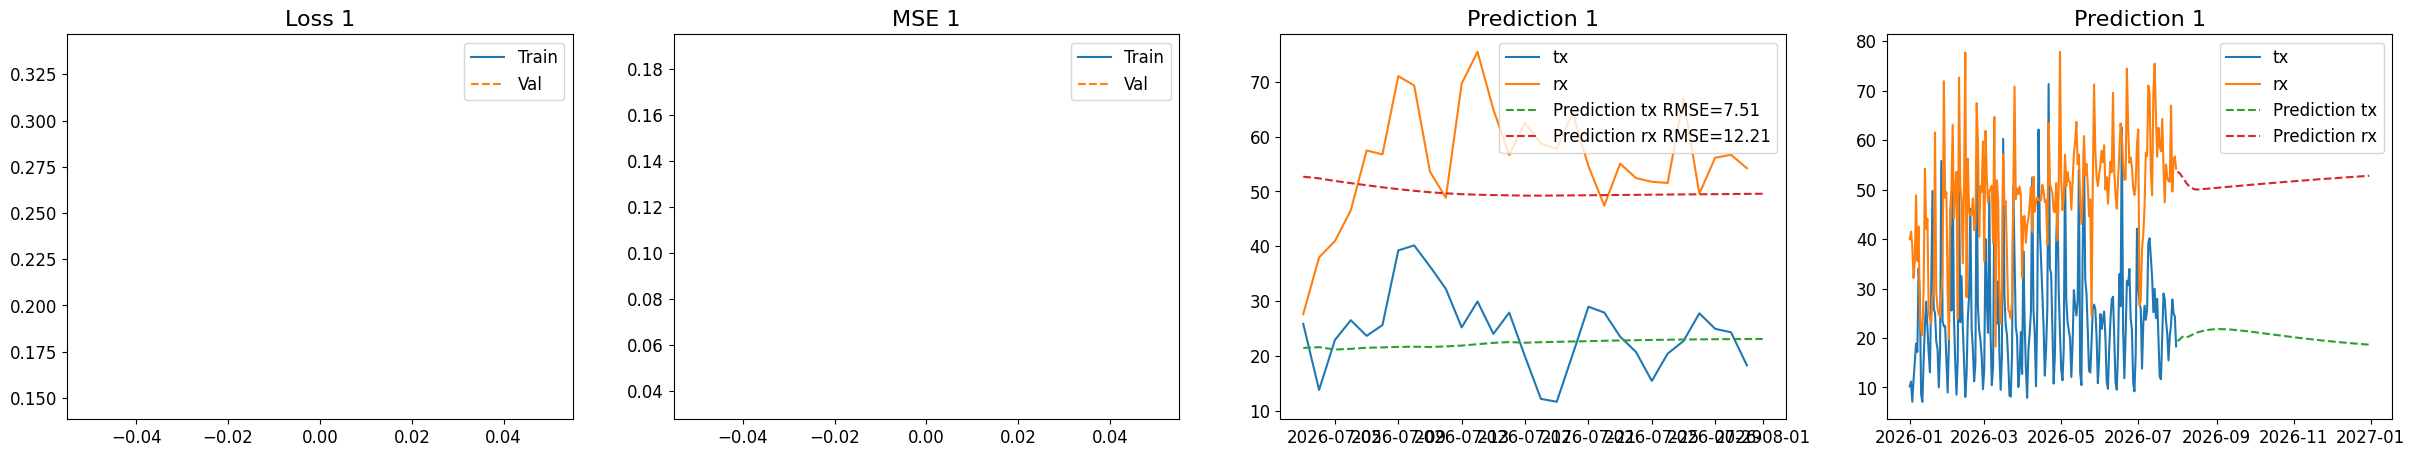

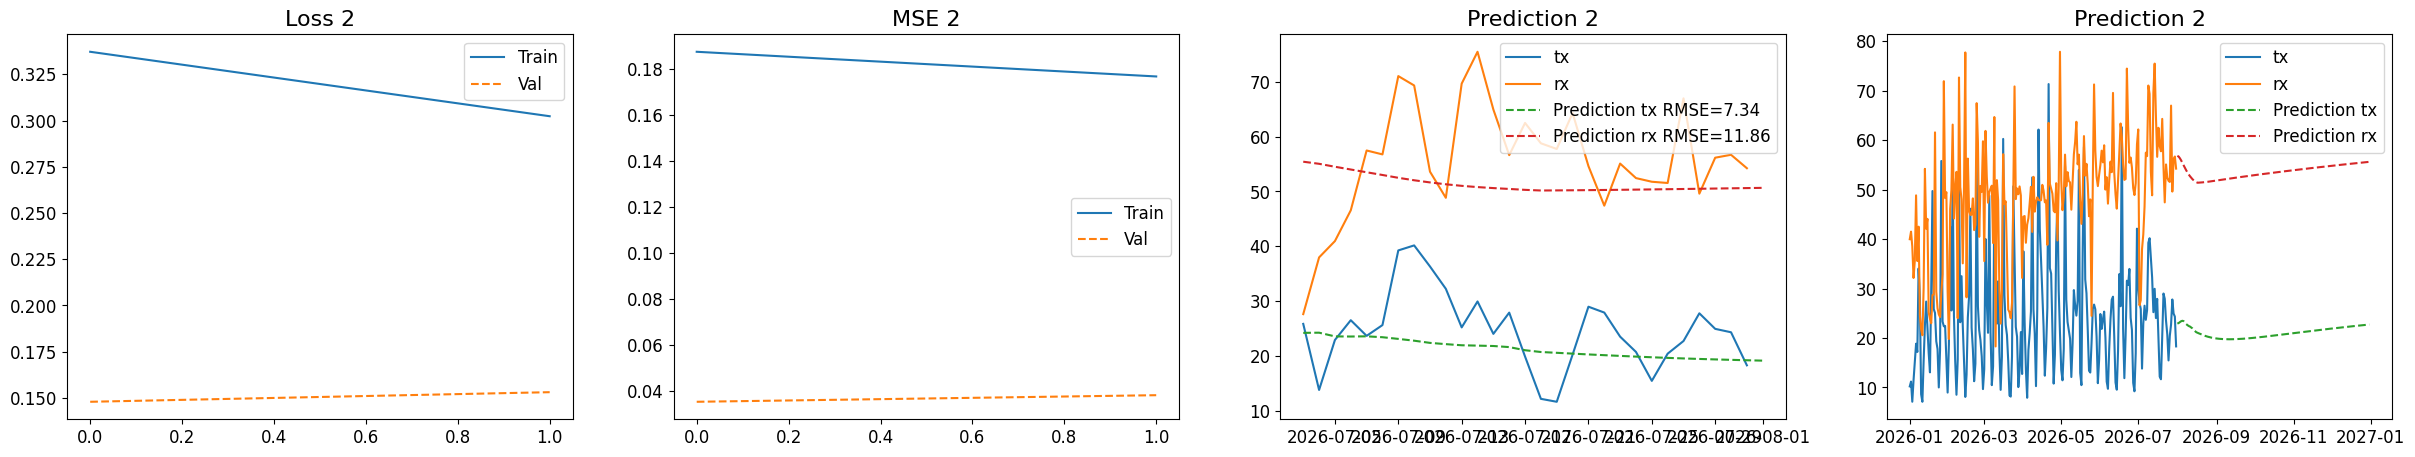

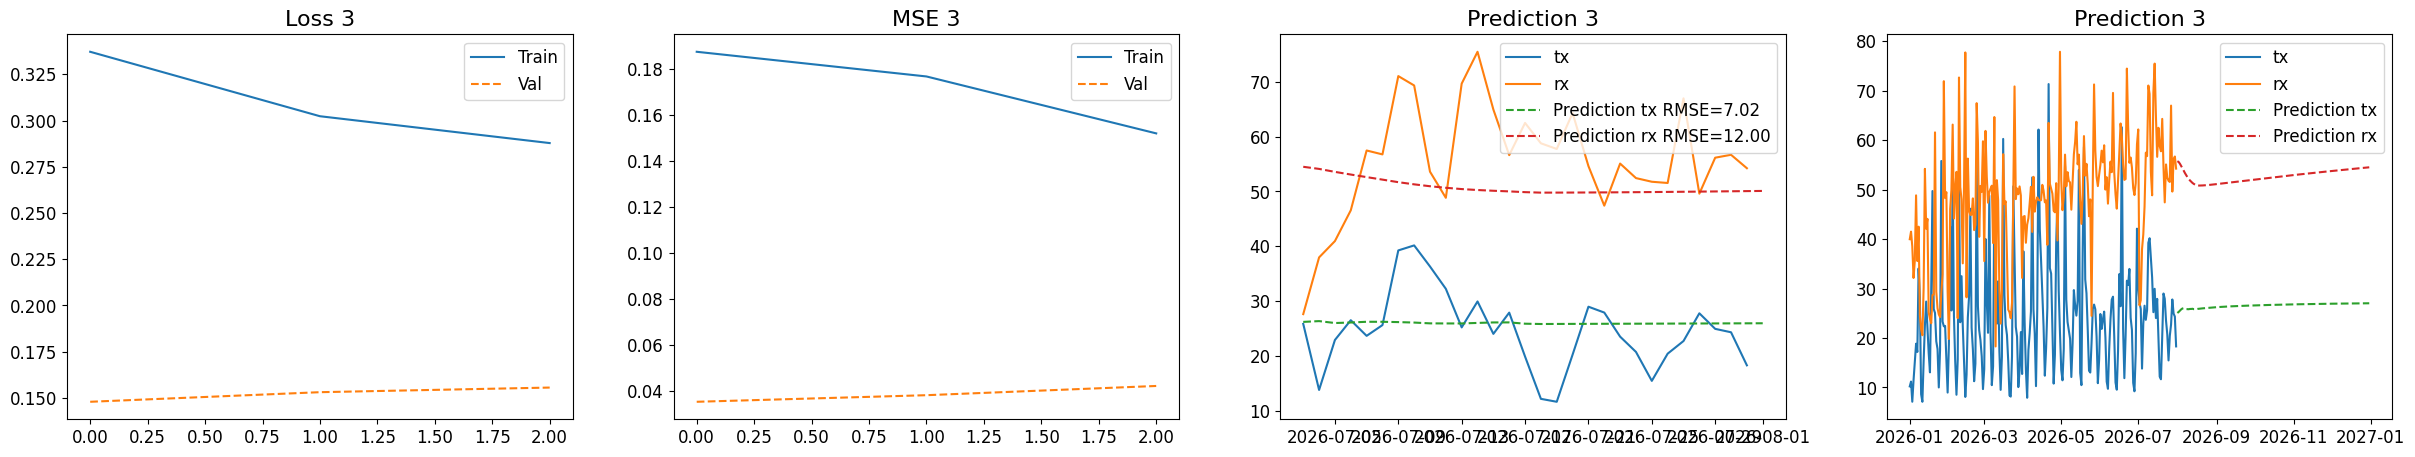

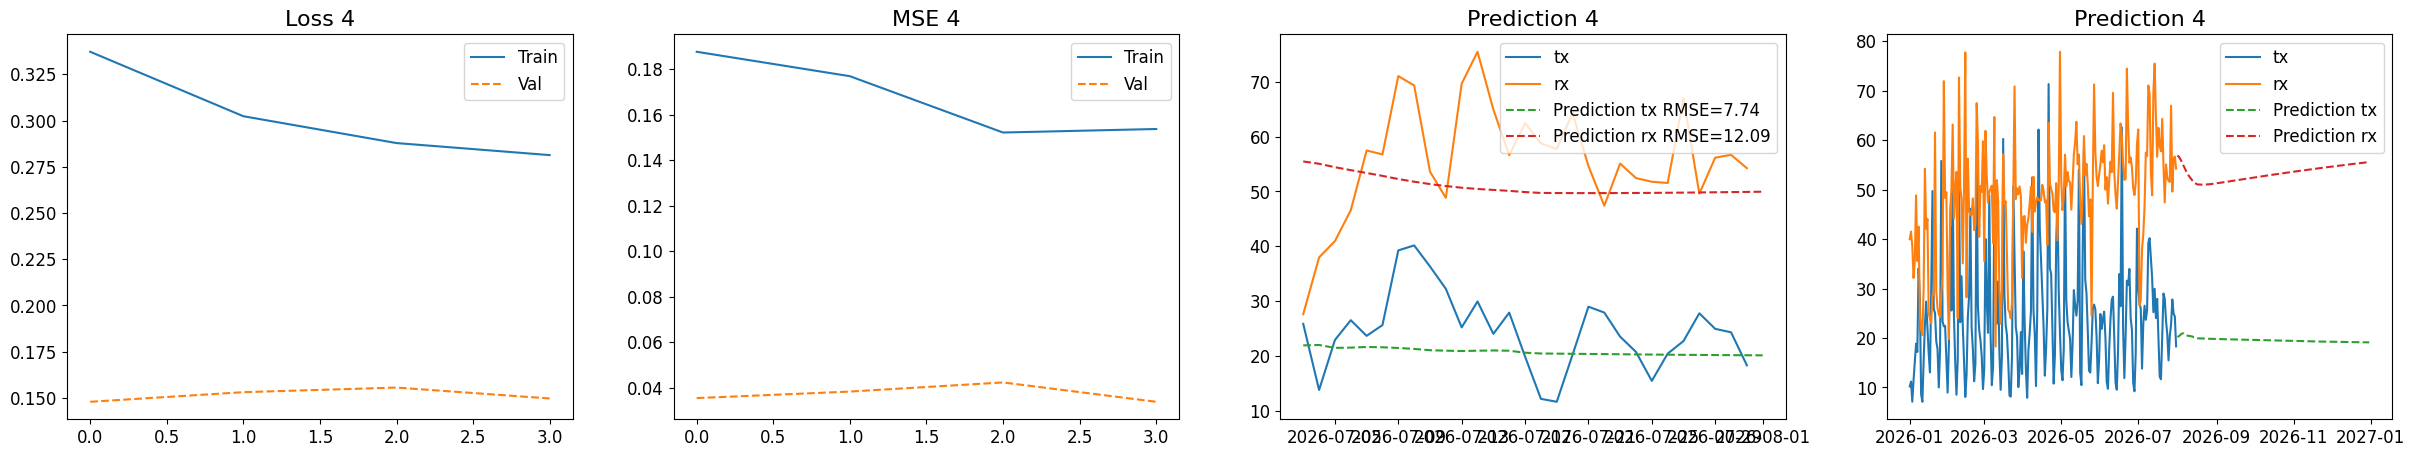

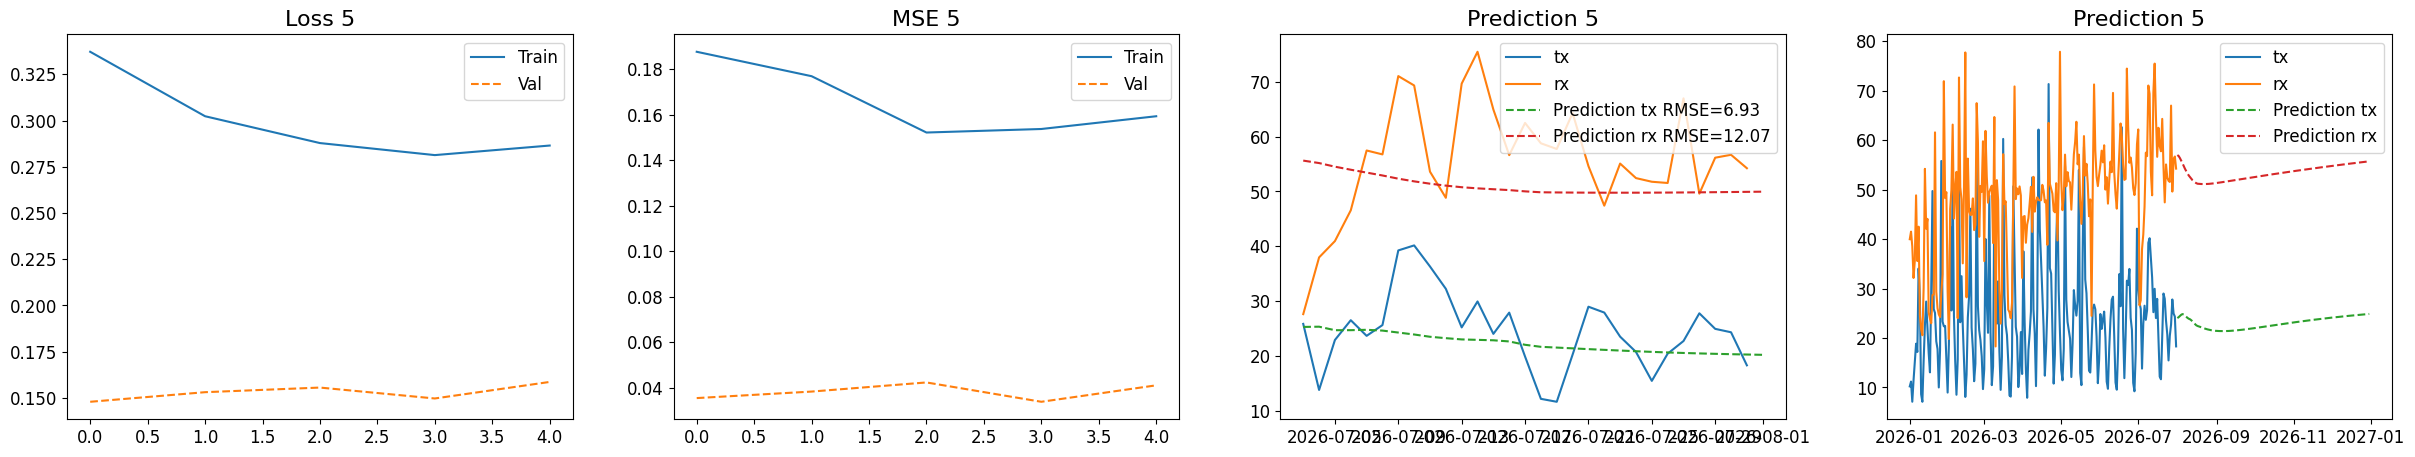

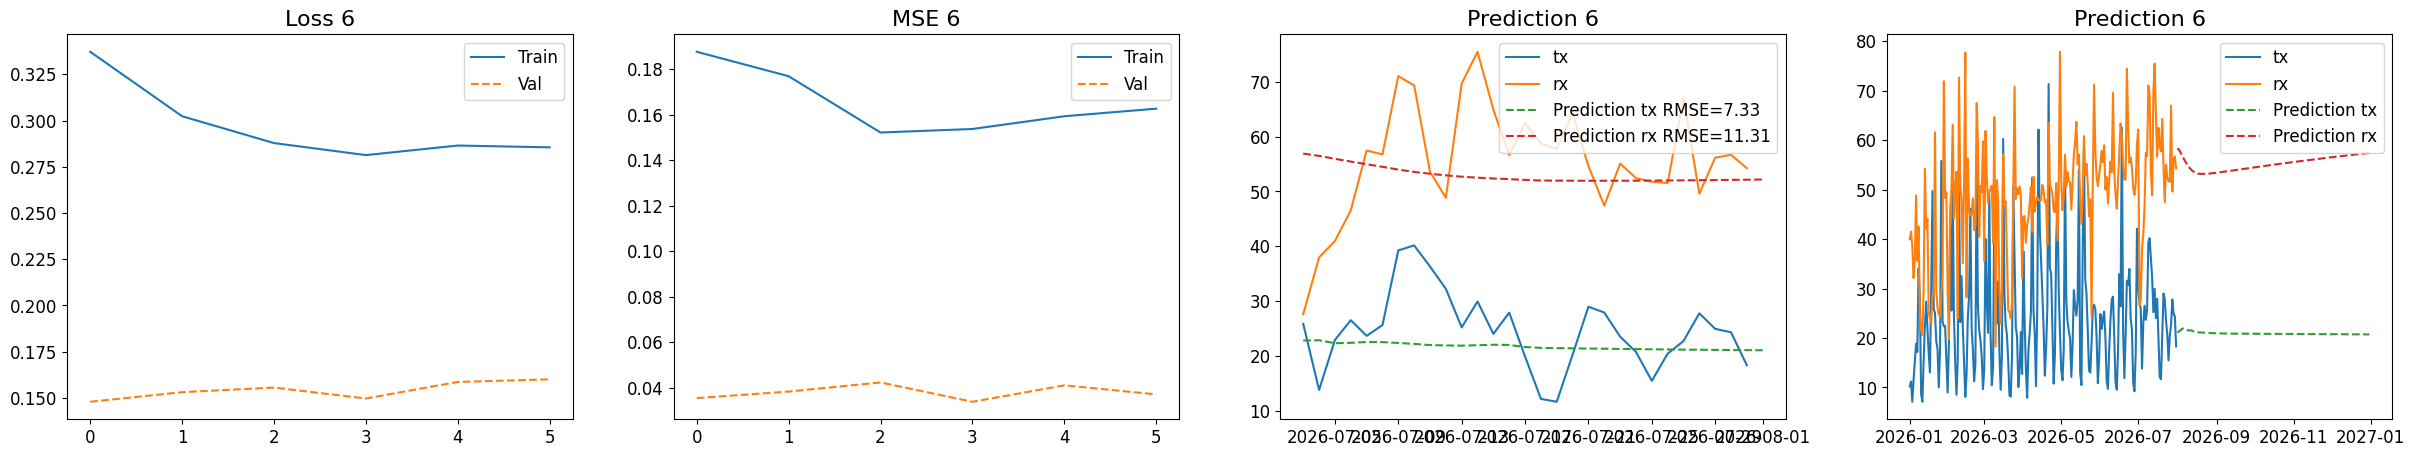

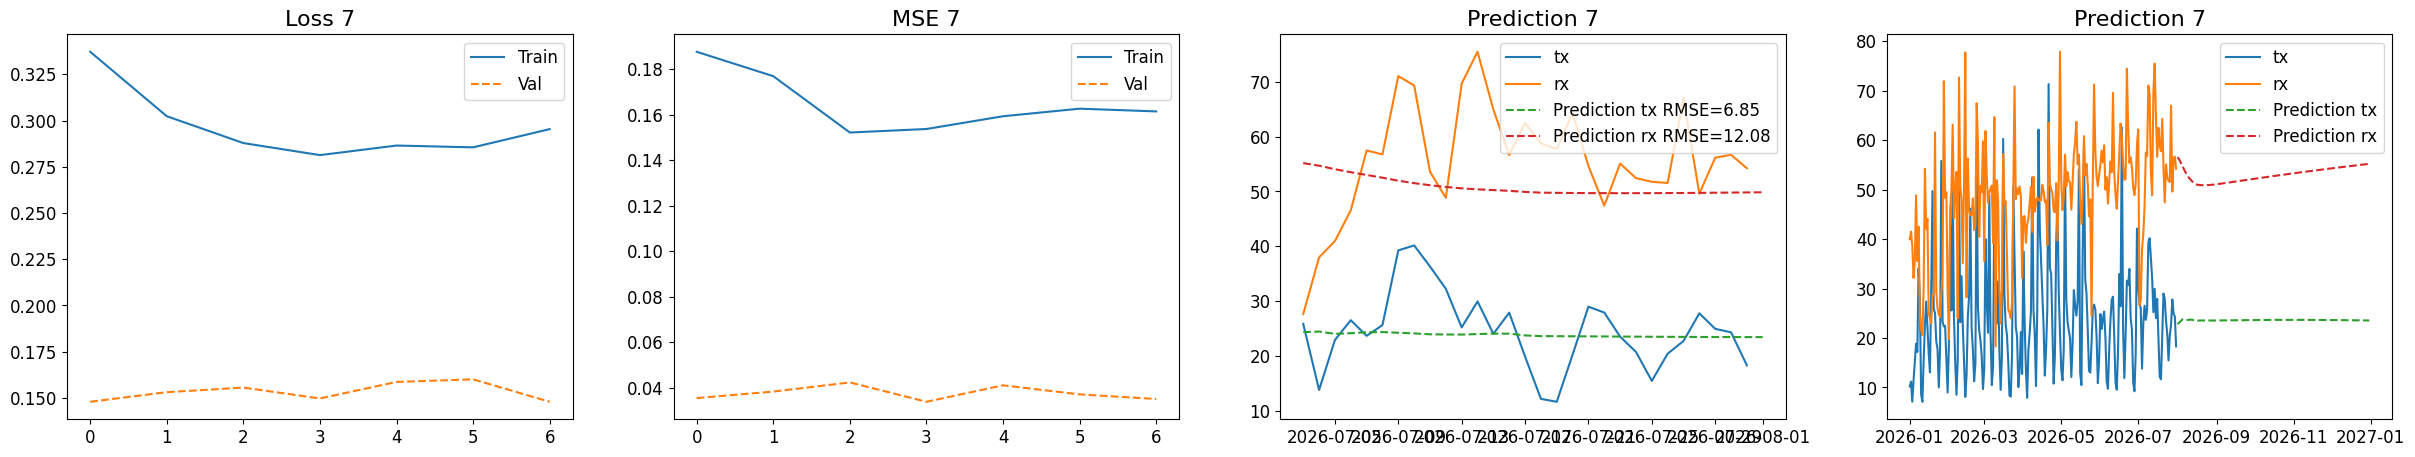

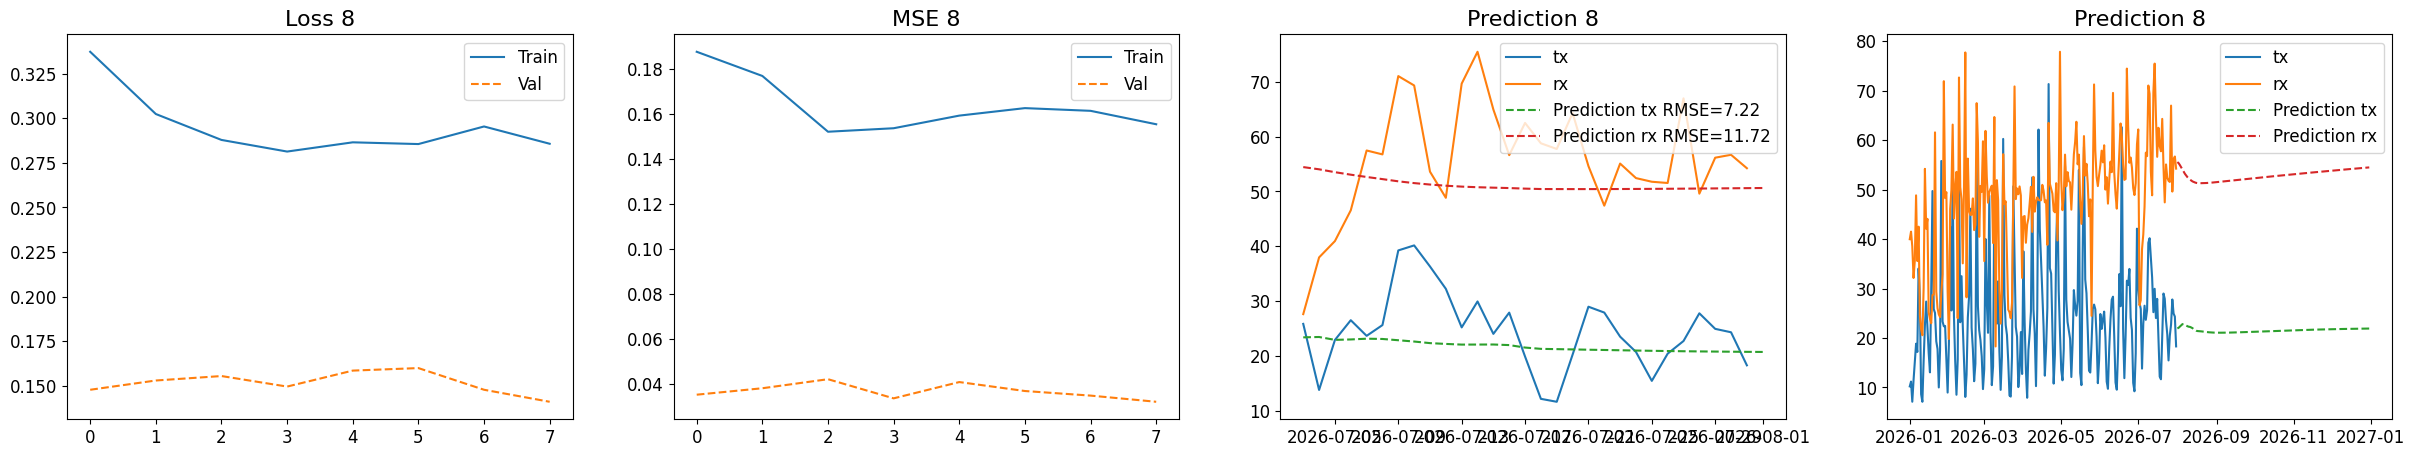

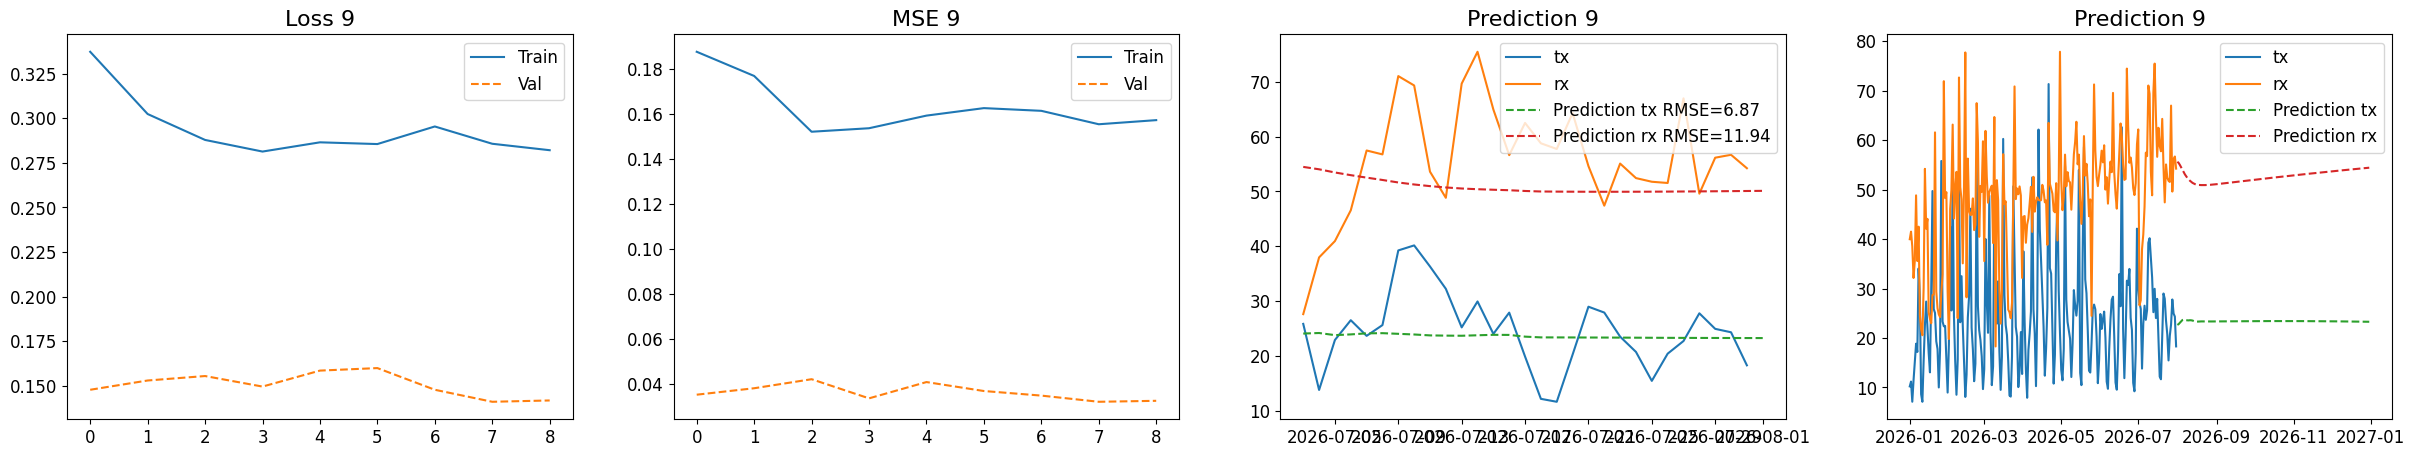

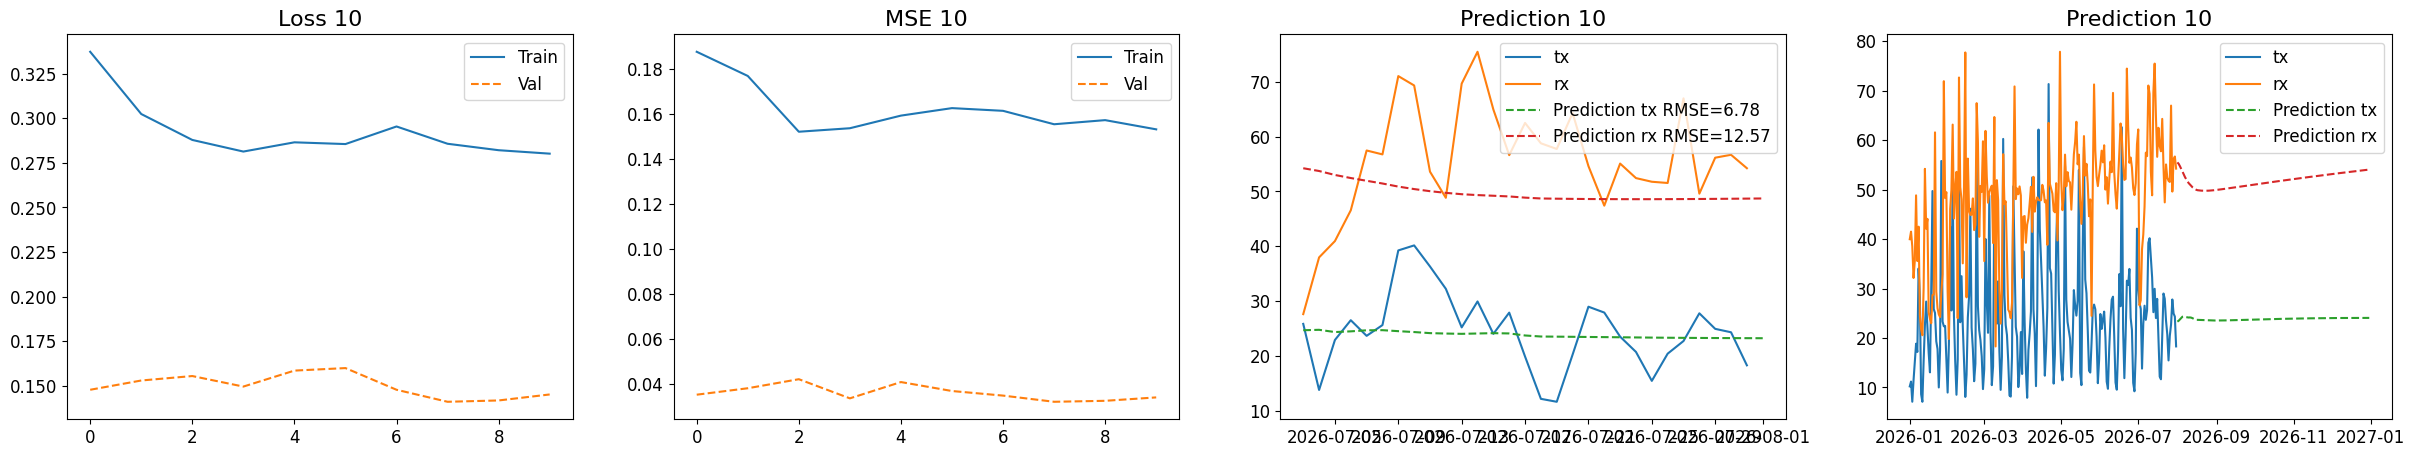

In [22]:
#loss, val_loss, acc, val_acc, epochsx = plot_epochs(loss, val_loss, acc, val_acc, 1, epochsx, 10)
loss, val_loss, metric, val_metric, epochsx = plot_epochs(loss, val_loss, metric, val_metric, 1, epochsx, 10)

In [23]:
loss, val_loss, metric, val_metric, epochsx = plot_epochs(loss, val_loss, metric, val_metric, 1, epochsx, 40)

Output hidden; open in https://colab.research.google.com to view.

In [24]:
loss, val_loss, metric, val_metric, epochsx = plot_epochs(loss, val_loss, metric, val_metric, 1, epochsx, 50)

Output hidden; open in https://colab.research.google.com to view.

In [25]:
#loss, val_loss, acc, val_acc, epochsx = plot_epochs(loss, val_loss, acc, val_acc, 1, epochsx, 100)
#loss, val_loss, metric, val_metric, epochsx = plot_epochs(loss, val_loss, metric, val_metric, 1, epochsx, 50)